# NB-SOLUTIONS — Python for Data Work
## Parts 1 and 2 · 0:00 – 0:55

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YouvenZ/ml-workshop-2h/blob/main/notebooks/NB1-python-data.ipynb)

**Click *Copy to Drive* before you start**, or nothing you type will be saved.

| | |
|---|---|
| **Grey cells** | code — run with `Shift + Enter` |
| **`___`** | a blank for you to fill in |
| **Stuck?** | flat hand. **Done?** thumbs up. |
| **Broken?** | Runtime → Restart and run all |

---
## Cell 1 — run this now

Do not read it yet. Click it, press **Shift + Enter**, and check you get a
table of penguins. We will explain every piece of this line in the next half hour.

In [ ]:
import pandas as pd

URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
df = pd.read_csv(URL)

print(f"Loaded {len(df)} penguins.")
df.head()

If you see a table: you are set up. That is the whole setup.

If you see a red error: raise a hand. Do not debug it alone — it is almost
certainly the network, not you.

---
---
# Part 1 — Python for data work · 0:05 – 0:30

Everything below is typed live on screen. Type along in the empty cells —
you will remember far more than by reading finished code.

## Variables and types

A variable is a **labelled box holding a value**. `=` means *"put this in
that box"*, not "is equal to".

In [ ]:
# variables and types
species     = 'Adelie'      # str  — text
body_mass_g = 3750          # int  — whole number
bill_mm     = 39.1          # float — decimal
is_adult    = True          # bool — True / False

print(type(species), type(body_mass_g), type(bill_mm), type(is_adult))
print(f"A {species} weighing {body_mass_g} g")

<p align="center">
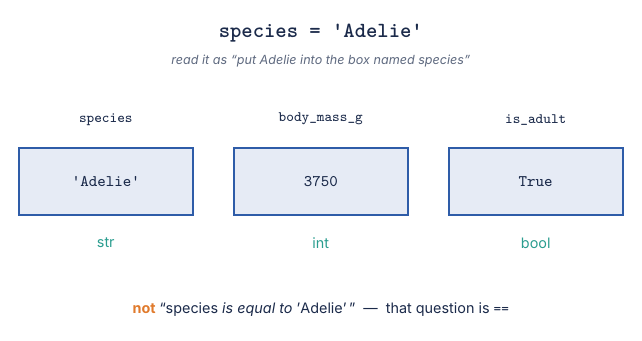
</p>

<div style="border-left:5px solid #E07A2C;background:#FDF2E9;padding:10px 16px;margin:14px 0;border-radius:4px;">
<div style="color:#E07A2C;font-weight:700;font-size:12px;letter-spacing:.09em;margin-bottom:4px;">WATCH OUT</div>
<code>=</code> puts a value in a box. <code>==</code> asks whether two things are equal. Mixing them up is the single most common first error in Python.
</div>

## Lists — ordered, indexed, sliceable

One value is rarely enough. A list holds many, **in order**, and remembers
that order.

In [ ]:
# lists
masses = [3750, 3800, 3250, 3450]

masses[0]      # first  — Python counts from 0
masses[-1]     # last
masses[:2]     # first two — a slice
len(masses)    # how many

masses.append(4100)
print(masses)

## Dicts — lookup by name, not by position

A list answers *"what is at position 2?"*. A dict answers *"what is the
mass?"*. One row of a table is naturally a dict.

In [ ]:
# dicts
penguin = {'species': 'Adelie', 'mass': 3750, 'island': 'Torgersen'}

penguin['mass']
penguin.keys()
penguin['mass'] = 3800      # values can be changed
print(penguin)

<p align="center">
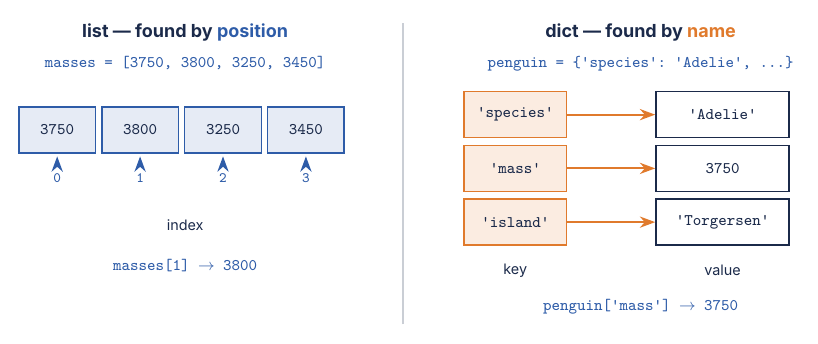
</p>

<div style="border-left:5px solid #2A9D8F;background:#ECF7F5;padding:10px 16px;margin:14px 0;border-radius:4px;">
<div style="color:#2A9D8F;font-weight:700;font-size:12px;letter-spacing:.09em;margin-bottom:4px;">THE POINT</div>
A list answers <i>“what is at position 2?”</i>. A dict answers <i>“what is the mass?”</i>. One row of the table you loaded is naturally a dict.
</div>

## Loops and conditionals

A **loop** does the same thing to every item. A **conditional** chooses
between two paths.

> The indentation is not decoration — it is what tells Python which lines are
> *inside* the loop. And `==` asks a question; `=` gives an answer.

In [ ]:
# loops and conditionals
for m in masses:
    if m > 3700:
        print(m, 'heavy')
    else:
        print(m, 'light')

## Functions — name a piece of work so you can reuse it

In [ ]:
# functions
def size_label(mass_g):
    return 'large' if mass_g > 3700 else 'small'

print(size_label(3750))
print(size_label(3250))

# a function is most useful applied to many values at once:
for m in masses:
    print(m, size_label(m))

---
## NumPy — the same operations, on the whole column at once

A Python list of numbers is a list of *objects scattered in memory*. A NumPy
array is **one contiguous block of numbers**. That difference is why it is
fast, and why every data library in Python is built on it.

In [ ]:
# numpy arrays
import numpy as np

a = np.array([3750, 3800, 3250, 3450])
print(a)
print(a.shape, a.dtype)

<p align="center">
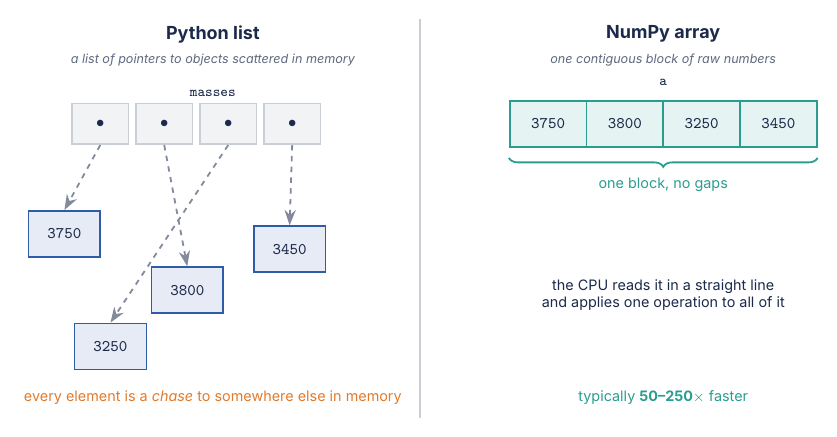
</p>

### Vectorised: no loop needed

This is the idea that makes the rest of the workshop possible. One operation
applies to **every element**, with no `for` in sight.

In [ ]:
# vectorised operations
a * 2            # every element doubled — no loop
a + 100

a.mean(), a.std(), a.max(), a.min()

### Boolean masking — the bridge to Pandas

`a > 3700` does not give you `True` or `False`. It gives you **one answer per
element**. Feed that back in as an index and you keep only the `True` ones.

Remember this — Pandas filtering is exactly the same idea on a whole table.

In [ ]:
# boolean masking
mask = a > 3700
print(mask)          # one True/False per element

print(a[mask])       # keep only where True
print(a[a > 3700])   # normally written in one line
print((a > 3700).sum())   # True counts as 1 — so this counts them

### The speed demo

One million numbers. Same sum, two ways. Watch the units — one says
milliseconds, the other says microseconds.

In [ ]:
big = np.random.rand(1_000_000)

In [ ]:
%timeit sum(big)          # Python loop

In [ ]:
%timeit big.sum()         # NumPy

> That gap is typically **50–250×** depending on the machine. It is the
> entire answer to
> *"why not just use a list?"*.

---
## Pandas — NumPy with names on the rows and columns

A **DataFrame** is a table. Each column is a **Series** — a NumPy array that
knows its own name and dtype.

In [ ]:
# first look at a dataframe
df.head()          # first five rows
df.shape           # (rows, columns)
df.columns         # column names
df.info()          # dtypes AND missing values, in one view

<p align="center">
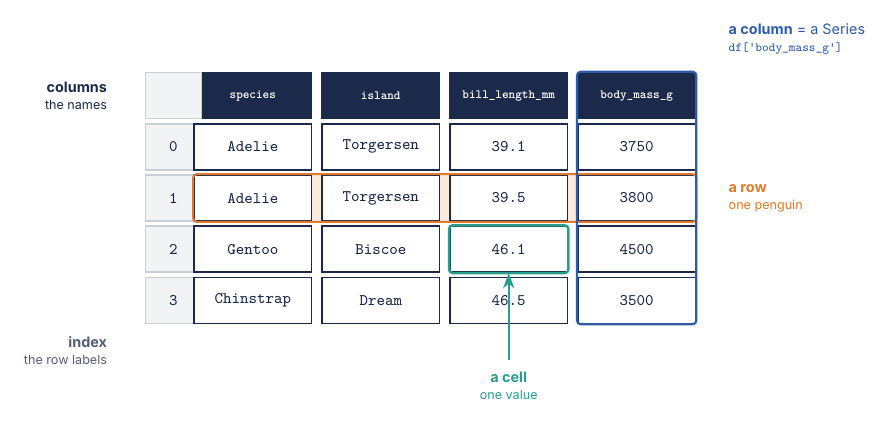
</p>

<div style="border-left:5px solid #2E5CA8;background:#EDF2FA;padding:10px 16px;margin:14px 0;border-radius:4px;">
<div style="color:#2E5CA8;font-weight:700;font-size:12px;letter-spacing:.09em;margin-bottom:4px;">WHY</div>
Every question you ask of this table is some combination of picking <b>columns</b> and filtering <b>rows</b>. That is most of pandas.
</div>

### Selecting columns

**One bracket gives a Series. Two brackets give a DataFrame.** That
distinction will cause you an error in Part 3, so meet it now.

In [ ]:
# selecting columns
df['body_mass_g']                  # one column  -> Series
df[['species', 'body_mass_g']]     # a list of columns -> DataFrame

type(df['body_mass_g']), type(df[['body_mass_g']])

### Filtering rows

Exactly the boolean mask you just met, applied to a table.

> With more than one condition, wrap **each** in parentheses and join with
> `&` (and) or `|` (or). Not `and` / `or` — those fail on whole columns.

In [ ]:
# filtering rows
df[df['body_mass_g'] > 4500]

df[(df['species'] == 'Gentoo') & (df['body_mass_g'] > 5000)]

# how many rows came back?
df[df['body_mass_g'] > 4500].shape[0]

---
# Exercise 1 — 5 minutes

Three short tasks. Fill in every `___`. Work with the person next to you.

Thumbs up when you are done, flat hand if you are stuck.

**Task 1.** Write a function that labels a flipper `'long'` above 210 mm, else `'short'`.

In [ ]:
def flipper_label(mm):
    if mm > 210:
        return 'long'
    else:
        return 'short'


# check yourself — this should print:  long   short
print(flipper_label(215))
print(flipper_label(190))

# the same thing written the short way:
def flipper_label_short(mm):
    return 'long' if mm > 210 else 'short'

**Task 2.** How many penguins are heavier than the average penguin?

In [ ]:
masses = df['body_mass_g'].dropna().to_numpy()

average = masses.mean()               # the mean of the array
above   = masses[masses > average]    # keep only those above it

print(f"{len(above)} of {len(masses)} penguins are above the mean mass")

# note it is NOT half — the distribution is not symmetric, because
# Gentoos are much heavier than the other two species.

**Task 3.** How many Chinstrap penguins are in the dataset?

In [ ]:
chinstraps = df[df['species'] == 'Chinstrap']

print(chinstraps.shape[0], "Chinstrap penguins")   # 68

# value_counts() answers this for every species at once — Part 2:
df['species'].value_counts()

### Checkpoint

> Given `df`, what does this return — a penguin, a number, or a table?
>
> ```python
> df[df['body_mass_g'] > 4000].shape[0]
> ```

Decide before you run it. Then run it.

In [ ]:
df[df['body_mass_g'] > 4000].shape[0]

---
---
# Part 2 — Wrangling and visualisation · 0:30 – 0:55

Same data, harder questions. By the end of this part you will have made the
one chart that the whole second hour depends on.

<p align="center">
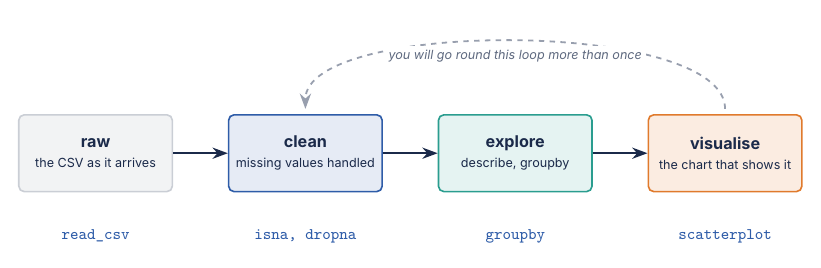
</p>

## Summarising

Three methods answer most first questions about a dataset.

In [ ]:
# summarising
df.describe()                  # count/mean/std/min/quartiles/max, numeric only
df['species'].value_counts()   # how many of each category
df['island'].value_counts()

## Missing values — a decision, not a command

`df.isna().sum()` counts the gaps in each column.

> **Before you run the next cell, answer out loud:** if we delete every row
> with any missing value, what have we lost? Is that acceptable here?

In [ ]:
# finding missing values
df.isna().sum()

In [ ]:
# dropping missing values — after discussing it
print("before:", df.shape)
df = df.dropna()
print("after: ", df.shape)

# 11 rows gone out of 344. Cheap here. On a medical dataset, the rows with
# missing values are often the *interesting* ones, and dropping them silently
# would be the whole error.

## Split, apply, combine — `groupby`

*"Split the rows into groups, compute something per group, put the answers
back together."* It is the single most used operation in data work.

In [ ]:
# groupby
df.groupby('species')['body_mass_g'].mean()

df.groupby(['species', 'sex'])['flipper_length_mm'].agg(['mean', 'count'])

df.sort_values('body_mass_g', ascending=False).head()

---
## Visualisation

Three charts, in order of how much they tell you.

<p align="center">
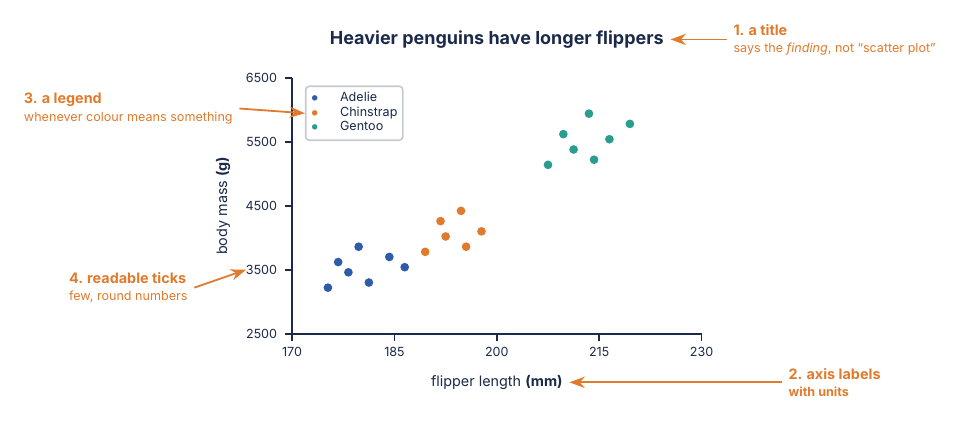
</p>

<div style="border-left:5px solid #2A9D8F;background:#ECF7F5;padding:10px 16px;margin:14px 0;border-radius:4px;">
<div style="color:#2A9D8F;font-weight:700;font-size:12px;letter-spacing:.09em;margin-bottom:4px;">THE POINT</div>
Every chart you produce today gets a title, both axes labelled <b>with units</b>, and a legend if colour means anything. This is the standard, not a nag.
</div>

In [ ]:
# a histogram — the shape of one variable
import matplotlib.pyplot as plt
import seaborn as sns

df['body_mass_g'].hist(bins=30)
plt.xlabel('body mass (g)')
plt.ylabel('count')
plt.title('Mass distribution')
plt.show()

# Two humps. That is not noise — it is Gentoos versus everyone else.

In [ ]:
# a scatter — two variables together
sns.scatterplot(data=df, x='flipper_length_mm', y='body_mass_g')
plt.title('A cloud')
plt.show()

### The one line that the whole workshop turns on

Add **one argument** to the chart you just made.

In [ ]:
# the same scatter, coloured by species
sns.scatterplot(data=df, x='flipper_length_mm', y='body_mass_g', hue='species')
plt.title('Three groups')
plt.show()

> The cloud was never a cloud. It was **three groups** all along.
>
> Those groups are what a classifier learns to draw a line between. That is
> the whole of Part 3, and you have just seen it with your own eyes.

In [ ]:
# correlation heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('How the numeric columns move together')
plt.show()

# numeric_only=True is required: corr() cannot average the word 'Adelie'.

---
# Independent practice — 8 minutes

Three questions. Answer each with code **and one chart where it helps**.
Work in pairs. Question 4 is a stretch for fast finishers — or homework.

**1.** Which species is heaviest on average?

In [ ]:
df.groupby('species')['body_mass_g'].mean().sort_values(ascending=False)
# Gentoo, ~5092 g — roughly 1.4 kg heavier than the other two
# (Adelie 3706, Chinstrap 3733).

**2.** How many penguins are on each island?

In [ ]:
df['island'].value_counts()
# Biscoe 163, Dream 123, Torgersen 47 (after dropna).

**3.** Do flipper length and body mass move together? Show it.

In [ ]:
sns.scatterplot(data=df, x='flipper_length_mm', y='body_mass_g', hue='species')
plt.xlabel('flipper length (mm)')
plt.ylabel('body mass (g)')
plt.title('Flipper length vs body mass')
plt.show()

df[['flipper_length_mm', 'body_mass_g']].corr()
# r = 0.87. Strong. But see the checkpoint below before you call it a law.

**4.** *Stretch — only if you finish early.* Pick any two variables and produce **one labelled chart
that tells a story**. Title, both axes labelled, legend if you used colour.

In [ ]:
# One of many good answers: bill shape separates the species even better
# than size does, which is a nice preview of 'feature choice matters'.
sns.scatterplot(data=df, x='bill_length_mm', y='bill_depth_mm', hue='species')
plt.xlabel('bill length (mm)')
plt.ylabel('bill depth (mm)')
plt.title('Bill shape separates the species almost perfectly')
plt.show()

### Checkpoint

> Flipper length and body mass are strongly correlated (r = 0.87).
> Does having longer flippers **cause** a penguin to weigh more?

---

## End of NB1

Next: **NB2 — Machine Learning**. It loads its own data in cell 1, so it does
not matter if anything in this notebook is broken.

# NB-SOLUTIONS — Machine Learning
## Parts 3 and 4 · 1:00 – 2:00

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YouvenZ/ml-workshop-2h/blob/main/notebooks/NB2-machine-learning.ipynb)

**Click *Copy to Drive* before you start.**

This notebook is **independent of NB1**. It loads and cleans its own data
below. If anything in NB1 went wrong, it does not matter now — run cell 1
and you are caught up with everyone else.

---
## Cell 1 — run this first, whatever happened in NB1

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
df = pd.read_csv(URL).dropna().reset_index(drop=True)

print(f"{len(df)} penguins, no missing values.")
df.head()

One line did the whole of Part 2's cleaning: `.dropna()`. You now know what
it cost us (11 rows) and why we accepted that.

---
---
# Part 3 — Concepts, then your first model · 1:00 – 1:30

## The four ideas

**1. Supervised vs unsupervised.** Supervised learning has an *answer key* —
we know each penguin's species and the model learns to reproduce it.
Unsupervised has no answer key; the model finds groupings on its own.
Today is entirely supervised.

**2. Features and labels.** In the table you already know:

- the columns we learn **from** are the **features**, called `X`
- the column we learn **to predict** is the **label**, called `y`

**3. Train / test split.** We hide some rows from the model, then test it on
those. *You do not grade a student on the exact questions they studied.*

**4. Overfitting.** A model can memorise the training rows instead of
learning the pattern. It then scores brilliantly on what it has seen and
badly on anything new. The gap between those two scores is the warning sign.

> Write each of those four in **your own words** in the cell below. Not for
> marks — putting it in your own words is how you find out whether you have it.

*Your definitions (double-click to edit this cell):*

1. Supervised vs unsupervised —
2. Features and labels —
3. Train / test split —
4. Overfitting —

<p align="center">
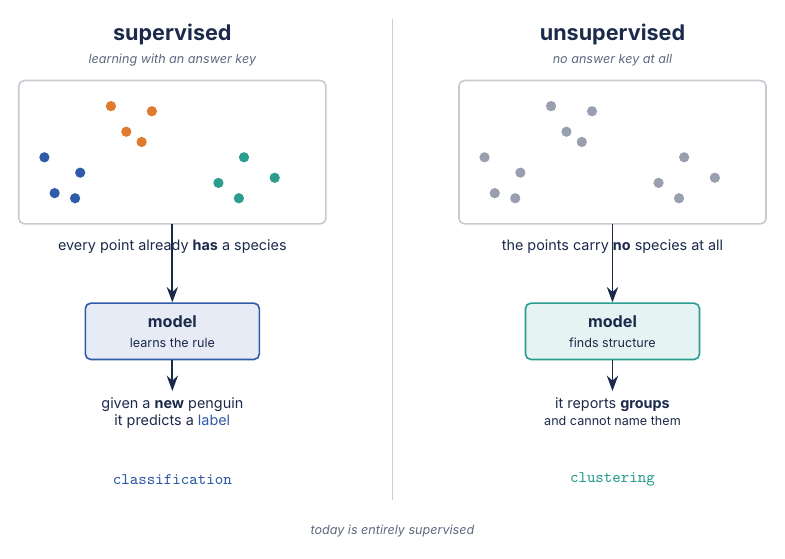
</p>

<p align="center">
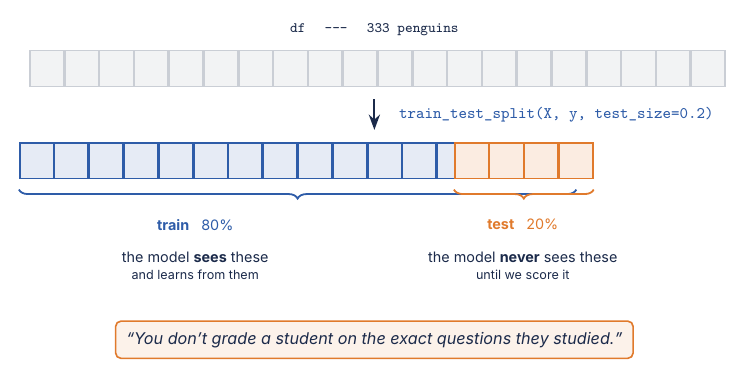
</p>

---
## Features and labels, on our data

In [ ]:
# define X and y
X = df[['flipper_length_mm', 'body_mass_g', 'bill_length_mm']]   # features
y = df['species']                                                # label

print(X.shape, y.shape)
X.head()

> `X` uses **double** brackets (a DataFrame, many columns), `y` uses **single**
> (a Series, one column). Get this backwards and `.fit()` fails — which is the
> single most common error in the next twenty minutes.

## Split, fit, predict, score

These four lines are the pattern. If you remember nothing else from today,
remember this shape.

In [ ]:
# the split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("train:", X_train.shape[0], " test:", X_test.shape[0])

# random_state=42 makes the split reproducible. Without it you get a
# different split every run and cannot compare two models honestly.

In [ ]:
# fit the model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

> **That was it.** `.fit()` is the line the entire workshop was building
> toward. Everything before it was getting the data into a shape this line
> accepts; everything after it is checking whether to believe it.

In [ ]:
# predict and score
from sklearn.metrics import accuracy_score

preds = model.predict(X_test)
accuracy_score(y_test, preds)

---
## Evaluate honestly

Accuracy is one number and it hides things. A confusion matrix shows you
*which* classes it confuses.

In [ ]:
# confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.show()

# Rows are the truth, columns are the prediction. Everything off the
# diagonal is a mistake — and it tells you which pair it mixes up.

<p align="center">
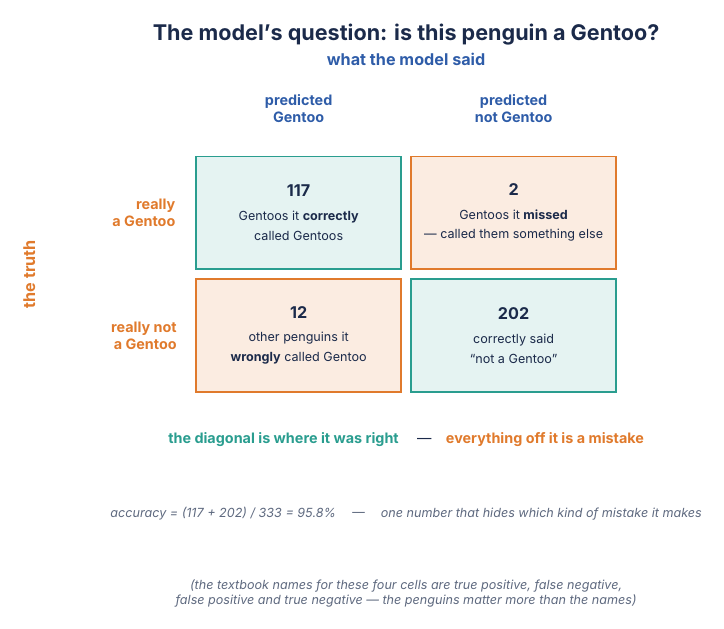
</p>

<div style="border-left:5px solid #2A9D8F;background:#ECF7F5;padding:10px 16px;margin:14px 0;border-radius:4px;">
<div style="color:#2A9D8F;font-weight:700;font-size:12px;letter-spacing:.09em;margin-bottom:4px;">THE POINT</div>
The diagonal is where it was right. Everything off the diagonal is a mistake — and the matrix tells you <i>which</i> pair the model confuses, which a single accuracy number never can.
</div>

### Now look at a penguin it got wrong

Accuracy is a number. A misclassified row is a story.

In [ ]:
# inspect the mistakes
wrong = X_test[preds != y_test].copy()
wrong['actual']    = y_test[preds != y_test]
wrong['predicted'] = preds[preds != y_test]
wrong

# Pick one and ask the room: why would the model confuse this penguin?
# Usually it sits right on the boundary between two species — small Gentoo,
# large Chinstrap. The model is not stupid; the data genuinely overlaps there.

### Checkpoint

> Our model scores about 97% on the **test** set. Suppose I now score it on
> the **training** set and get 100%. Is that good news?

In [ ]:
# train accuracy vs test accuracy
print("train accuracy:", round(model.score(X_train, y_train), 4))
print("test  accuracy:", round(model.score(X_test,  y_test), 4))

# A small gap is normal. A large gap is overfitting. Training accuracy on
# its own was never the number that mattered.

---
---
# Part 4 — A second model, and the scaling trap · 1:30 – 2:00

**K-Nearest Neighbors** does not learn an equation. To classify a new
penguin it finds the `K` most similar penguins it has already seen, and
takes a vote.

"Most similar" means **closest** — and that is where it gets interesting.

### First, run it on the raw numbers

In [ ]:
# KNN, unscaled
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

acc_unscaled = accuracy_score(y_test, knn.predict(X_test))
print("unscaled:", round(acc_unscaled, 4))

That is noticeably worse than logistic regression. **Why?**

Look at the numbers: body mass is in the *thousands*, bill length in the
*tens*. When KNN measures distance, a 500 g difference in mass swamps a 5 mm
difference in bill — so it is effectively using mass alone and ignoring the
other two features entirely.

**Scaling** puts every feature on the same footing.

<p align="center">
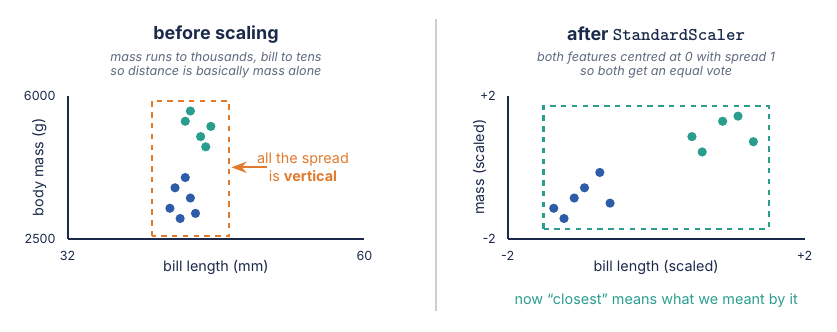
</p>

<div style="border-left:5px solid #2E5CA8;background:#EDF2FA;padding:10px 16px;margin:14px 0;border-radius:4px;">
<div style="color:#2E5CA8;font-weight:700;font-size:12px;letter-spacing:.09em;margin-bottom:4px;">WHY</div>
KNN works out <b>distance</b>: <code>d = sqrt(Δbill² + Δmass²)</code>. For two penguins 5 mm and 500 g apart that is <code>sqrt(25 + 250000)</code> — mass contributes 250 000, bill contributes 25. Bill length is <b>0.01%</b> of the answer.
</div>

In [ ]:
# KNN, scaled
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)     # learn mean+std from TRAIN only

knn.fit(scaler.transform(X_train), y_train)
acc_scaled = accuracy_score(y_test, knn.predict(scaler.transform(X_test)))

print("unscaled:", round(acc_unscaled, 4))
print("scaled:  ", round(acc_scaled, 4))

> **Fit the scaler on the training set only.** If you fit it on all the data,
> information from the test set leaks into training and your score becomes a
> flattering lie. This is the most common subtle bug in applied ML.

Models have **preconditions**. KNN needs scaled features; logistic regression
mostly shrugs. Knowing which is which is most of the craft.

### Optional: does K matter?

In [ ]:
for k in [1, 3, 5, 15, 50]:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(scaler.transform(X_train), y_train)
    print(k, round(accuracy_score(y_test, m.predict(scaler.transform(X_test))), 4))

# K=1 trusts the single nearest neighbour — jagged, and noise-sensitive.
# Very large K smooths so much it starts ignoring real structure.
# K is a *hyperparameter*: we choose it, the model does not learn it.

---
---
# The Titanic challenge — 12 minutes, in pairs

A messier dataset, on purpose. Penguins were tidy; almost nothing real is.

Your job: get from a raw CSV to a score, using the pattern you now know.
**Nobody is going to tell you the steps in order again.**

In [ ]:
tdf = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
print(tdf.shape)
tdf.head()

### Step 1 — explore

What columns are there? What are you predicting? What is missing?

In [ ]:
tdf.info()
print(tdf.isna().sum())
tdf['Survived'].value_counts()

# 891 rows. 'Survived' is the label: 1 = survived, 0 = did not.
# Age is missing for 177 passengers, Cabin for 687 (unusable), Embarked for 2.

### Step 2 — handle the missing `Age`

177 of 891 passengers have no recorded age. You have three options, and
**all three cost something**:

| option | what it costs |
|---|---|
| **drop the rows** | 20% of your data — and they are not a random 20% |
| **fill with a constant** (`0`, `-1`) | invents an age that is not an age |
| **fill with a statistic** (mean, median) | keeps every row, distorts the distribution |

Filling a gap is called **imputation**. The word matters because it is honest
about what you are doing:

<div style="border-left:5px solid #2A9D8F;background:#ECF7F5;padding:10px 16px;margin:14px 0;border-radius:4px;">
<div style="color:#2A9D8F;font-weight:700;font-size:12px;letter-spacing:.09em;margin-bottom:4px;">THE POINT</div>
You are not <i>recovering</i> the missing value. You are <b>inventing</b> one. Every imputed passenger gets the <i>same</i> invented age, so they all pile up in one place.
</div>

Run the cell below to see what a median fill does to the shape of the column
before you decide.

In [ ]:
import matplotlib.pyplot as plt

bins = range(0, 85, 5)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)

ax[0].hist(tdf['Age'].dropna(), bins=bins, color='#2E5CA8')
ax[0].set_title(f"observed  (n={tdf['Age'].notna().sum()})")

ax[1].hist(tdf['Age'].fillna(tdf['Age'].median()), bins=bins, color='#E07A2C')
ax[1].set_title(f"after filling with the median ({tdf['Age'].median():.0f})")

for a in ax:
    a.set_xlabel('age (years)')
ax[0].set_ylabel('passengers')
plt.tight_layout(); plt.show()

print("std before:", round(tdf['Age'].std(), 2))
print("std after: ", round(tdf['Age'].fillna(tdf['Age'].median()).std(), 2))

That spike is 177 people who now share one age. The column looks **less
variable than reality**, and a model reading it will be quietly overconfident
about 28-year-olds.

That may still be the right trade — but it is a trade, and you should be able
to say what you paid.

<div style="border-left:5px solid #E07A2C;background:#FDF2E9;padding:10px 16px;margin:14px 0;border-radius:4px;">
<div style="color:#E07A2C;font-weight:700;font-size:12px;letter-spacing:.09em;margin-bottom:4px;">WATCH OUT</div>
<b>Three rules for imputing.</b><br>1. Fit the imputer on the <b>training set only</b> — otherwise the median carries information from the test set into your model. Same leakage trap as fitting a scaler on all the data.<br>2. <b>Never impute the label.</b> Inventing answers is not cleaning.<br>3. <b>Record what you filled.</b> An <code>Age_was_missing</code> column of 0/1 costs nothing, and on the Titanic it is often predictive on its own — whose age went unrecorded was not random.
</div>

Now pick one and do it. Write one sentence below saying why.

In [ ]:
# Filling with the median keeps all 891 rows; dropping would throw away 20%
# of the data, and the passengers with no recorded age are not a random
# sample (more third-class). Median beats mean here because Age is skewed.

# Rule 3: record what we invented, BEFORE we overwrite it.
tdf['Age_was_missing'] = tdf['Age'].isna().astype(int)
tdf['Age'] = tdf['Age'].fillna(tdf['Age'].median())

print(tdf['Age'].isna().sum(), "missing ages remain")
print(tdf['Age_was_missing'].sum(), "rows flagged as imputed")

# Was the flag worth keeping? Survival rate differs between the two groups,
# so "we don't know this person's age" carries real information.
print(tdf.groupby('Age_was_missing')['Survived'].mean().round(3))

### Step 3 — make `Sex` numeric

scikit-learn cannot do arithmetic on the word `'female'`. Turn that column
into numbers.

In [ ]:
#@title 💡 Hint for step 3 — click to open only if you need it
# A column of two categories becomes a column of 0/1 like this:
#
#     tdf['Sex_num'] = tdf['Sex'].map({'male': 0, 'female': 1})
#
# For a column with MORE than two categories (like 'Embarked') you would use
# pd.get_dummies(), which makes one 0/1 column per category.

In [ ]:
tdf['Sex_num'] = tdf['Sex'].map({'male': 0, 'female': 1})

tdf[['Sex', 'Sex_num']].head()

### Step 4 — split, fit, predict, score

This is the real assessment. Same four lines as the penguins, new data.

In [ ]:
Xt = tdf[['Pclass', 'Sex_num', 'Age', 'SibSp']]
yt = tdf['Survived']

Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    Xt, yt, test_size=0.2, random_state=42)

tmodel = LogisticRegression(max_iter=1000)
tmodel.fit(Xt_train, yt_train)

tpreds = tmodel.predict(Xt_test)
print("accuracy:", round(accuracy_score(yt_test, tpreds), 4))   # ~0.80

# Worth saying out loud: always guessing "did not survive" scores 0.59 on
# this test split (62% of all passengers died). 0.80 is a real improvement
# over that baseline — but ALWAYS check the baseline first. On an imbalanced
# dataset a high-looking accuracy can mean the model learned nothing.
print("baseline (always predict 0):", round((yt_test == 0).mean(), 4))
ConfusionMatrixDisplay.from_estimator(tmodel, Xt_test, yt_test)
plt.show()

### Step 5 — *stretch:* does adding `Fare` help?

An honest experiment with an uncertain answer. Add it, re-run, compare.

In [ ]:
for cols in (['Pclass', 'Sex_num', 'Age', 'SibSp'],
             ['Pclass', 'Sex_num', 'Age', 'SibSp', 'Fare']):
    Xa = tdf[cols]
    Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(
        Xa, yt, test_size=0.2, random_state=42)
    m = LogisticRegression(max_iter=1000).fit(Xa_tr, ya_tr)
    print(f"{len(cols)} features: {accuracy_score(ya_te, m.predict(Xa_te)):.4f}")

# Usually barely moves. Fare carries much the same information as Pclass —
# a correlated feature is not a new feature. "More columns" is not a strategy.

---
## What you built today

    raw data  →  clean  →  split  →  train  →  evaluate  →  predict

You recognise every box in that line. That is the point.

<p align="center">
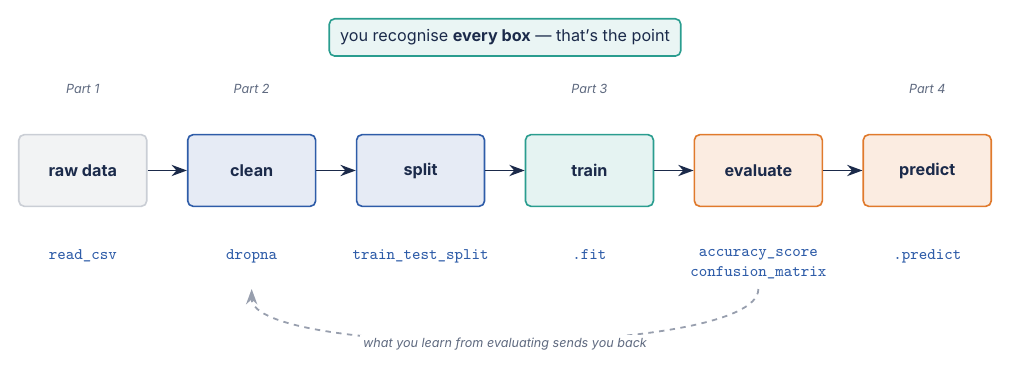
</p>

### Three next steps

1. **A course** — *[fill in your recommendation]*
2. **A dataset** — find one you actually care about and run this exact
   pipeline on it. That is how this becomes yours rather than ours.
3. **A community** — *[fill in your recommendation]*

> The most valuable thing you can take from today is not `.fit()`. It is the
> habit of looking at a prediction the model got **wrong** before believing
> the ones it got right.